# Day 3 Practical: Graph Neural Networks for Molecular Property Prediction
**AI for Drug Discovery**

## Overview

In this practical, you will:
1. **Represent molecules as graphs** — atoms become nodes, bonds become edges, and molecular properties become prediction targets
2. **Train a Graph Convolutional Network (GCN)** using DeepChem, a powerful open-source library for drug discovery ML
3. **Compare GNN performance to your Random Forest baseline** from Day 2 (Evaluation) to see when deep learning helps
4. **Analyze when GNNs outperform classical ML** — and importantly, when they don't!

### From Molecules to Neural Circuits: Graphs All the Way Down

The graph framework you will learn here extends far beyond chemistry. A **neural circuit** is also a graph: neurons are nodes, synapses are directed weighted edges. The *Drosophila* (fruit fly) connectome — the complete wiring diagram of an adult brain — was recently mapped by the FlyWire consortium (Dorkenwald et al., 2024, *Nature*), revealing **~140,000 neurons** and **~50 million synaptic connections**. This is literally a graph, and the same GNN message-passing framework we use for molecular property prediction can classify neuron types, predict circuit function, and identify drug targets in connectome data. The instructor, **Dr. Étienne Serbe-Kamp**, used electron microscopy (EM) connectomics to map synaptic inputs to motion-detecting neurons in the fly visual system (Serbe et al., 2016, *Neuron*) — work that bridges the molecular and circuit scales this course covers.

### Why Graph Neural Networks?

Traditional machine learning for molecules relies on **fixed fingerprints** (like ECFP/Morgan fingerprints) that encode molecular structure as bit vectors. While effective, these fingerprints:
- Are hand-designed and may miss important structural features
- Lose 3D spatial information
- Cannot be optimized for the specific prediction task

**Graph Neural Networks (GNNs)** take a fundamentally different approach: they **learn** molecular representations directly from the graph structure. The key innovation is **message passing** — an iterative process where each atom (node) collects information from its neighbors:

1. **Initialize**: Each atom starts with features (element type, charge, hybridization, etc.)
2. **Message**: Each atom sends a "message" to its neighbors — think of it like atoms gossiping about their local environment
3. **Aggregate**: Each atom collects messages from all neighbors and combines them (sum, mean, or max)
4. **Update**: Each atom updates its own representation based on collected messages
5. **Repeat**: Steps 2-4 repeat for K rounds. After K rounds, each atom "knows" about its K-hop neighborhood
6. **Readout**: All atom representations are pooled into a single molecular vector for prediction

**Intuitive analogy**: Imagine you're at a party and can only talk to people next to you. After round 1, you know about your immediate neighbors. After round 2, your neighbors tell you about *their* neighbors — so you know about people 2 steps away. After K rounds, you have information about everyone within K connections. This is exactly how GNNs work!

### Graph Representation of Molecules

A molecular graph consists of:
- **Adjacency Matrix (A)**: An N×N matrix where N is the number of atoms. A[i][j] = 1 if atoms i and j are bonded, 0 otherwise. This encodes the molecular topology.
- **Node Feature Matrix (X)**: An N×F matrix where F is the number of features per atom. Features include: atomic number, degree (number of bonds), formal charge, hybridization (sp, sp2, sp3), aromaticity, number of hydrogens, etc.
- **Edge Feature Matrix (E)**: Optionally, each bond can have features: bond type (single, double, triple, aromatic), conjugation, ring membership, stereochemistry (E/Z), etc.

For example, ethanol (C-C-O) has 3 heavy atoms, so its adjacency matrix is 3×3, and each atom has a feature vector describing its chemical properties.

### Prerequisites
- Completion of Weeks 1-3 (especially the RF model from Day 2 (Evaluation))
- Basic understanding of neural networks (activation functions, backpropagation, loss functions)
- Python familiarity with numpy, matplotlib, and scikit-learn


In [ ]:
# ============================================================
# INSTALLATION AND SETUP
# Install the package set that is compatible with this practical on Windows.
# dgl==1.1.2 avoids the missing GraphBolt DLL issue seen with newer wheels.
# dgllife is required by DeepChem's DGL-backed graph models.
# ============================================================
!pip install deepchem rdkit scikit-learn pandas matplotlib seaborn dgl==1.1.2 dgllife -q

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(
    'ignore',
    message='Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.*'
)


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\serbe\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
# ============================================================
# IMPORT LIBRARIES
# Each library serves a specific purpose in our GNN pipeline.
# ============================================================

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(
    'ignore',
    message='Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.*'
)

import logging
logging.getLogger('deepchem').setLevel(logging.ERROR)

import deepchem as dc
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem, Descriptors, Draw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

RDLogger.DisableLog('rdApp.*')
sns.set_theme(style='whitegrid')

print(f'DeepChem version: {dc.__version__}')
print('All imports successful!')

DeepChem version: 2.8.0
All imports successful!


## 1. Load a MoleculeNet Dataset

We'll use the **BACE** dataset: 1,513 compounds tested against **BACE-1** (Beta-site Amyloid precursor protein Cleaving Enzyme 1), a key target for Alzheimer's disease.

### Why BACE?
- BACE-1 cleaves amyloid precursor protein (APP) to produce amyloid-β peptides, which aggregate into plaques in Alzheimer's disease
- Inhibiting BACE-1 is a major therapeutic strategy (though clinical trials have been challenging)
- The dataset is a binary classification task: does a molecule inhibit BACE-1 (active=1) or not (active=0)?
- With ~1,500 molecules, it's small enough to train quickly but large enough to learn from

### How DeepChem Featurizes Molecules into Graphs
When we specify `featurizer='GraphConv'`, DeepChem converts each SMILES string into a graph:
1. **Parse SMILES** → RDKit molecular object
2. **Extract atoms** → Each atom becomes a node with features: atomic number, degree, formal charge, radical electrons, hybridization (one-hot: SP, SP2, SP3), aromaticity, total hydrogens
3. **Extract bonds** → Each bond becomes an edge with features: bond type (single/double/triple/aromatic), conjugation, ring membership
4. **Build graph** → Adjacency list + node feature matrix + edge feature matrix

### Scaffold Split
We use **scaffold splitting** instead of random splitting. This splits molecules based on their Murcko scaffolds (core ring systems), ensuring that the test set contains structurally novel molecules not seen during training. This is more realistic for drug discovery — you want to predict activity for *new* chemical series, not just interpolate within known series.

**Reference:** Wu, Z. et al. (2018). MoleculeNet: A Benchmark for Molecular Machine Learning. Chemical Science 9:513-530

### Molecules and Neural Circuits: Two Kinds of Biological Graphs

Just as molecular graphs have **atoms as nodes** and **bonds as edges**, neural circuits have **neurons as nodes** and **synapses as edges**. The BACE dataset represents **1,513 molecular graphs**. By comparison, the *Drosophila* connectome (Dorkenwald et al., 2024) represents **~140,000 neural "graphs"** — a single, massive network of neurons and ~50 million synaptic connections. The mathematical framework is identical: in both cases, **message passing** lets each node aggregate information from its neighbors to learn representations that capture local and global structure. The only difference is what the nodes, edges, and features represent.


In [5]:
# ============================================================
# LOAD THE BACE DATASET WITH GRAPH FEATURIZATION
# This is the critical step where molecules become graphs.
# ============================================================

# GCNModel in DeepChem 2.8 expects MolGraphConv-style graph objects.
# Pass the featurizer object directly because the string alias 'MolGraphConv'
# is not registered in this DeepChem build.
tasks, datasets, transformers = dc.molnet.load_bace_classification(
    featurizer=dc.feat.MolGraphConvFeaturizer(),
    splitter='scaffold'
)

train_dataset, valid_dataset, test_dataset = datasets

print(f'Task: {tasks}')
print(f'Training set: {len(train_dataset)} molecules')
print(f'Validation set: {len(valid_dataset)} molecules')
print(f'Test set: {len(test_dataset)} molecules')

Task: ['Class']
Training set: 1210 molecules
Validation set: 151 molecules
Test set: 152 molecules


## 2. Visualize Some Molecules from the Dataset

Before diving into modeling, it's essential to **look at your data**. Visualizing molecules helps you:
- Understand the chemical diversity in the dataset
- Spot potential issues (e.g., salts, fragments, very large molecules)
- Build chemical intuition about what makes a BACE-1 inhibitor

We'll render the first 12 molecules as 2D structure diagrams using RDKit's `Draw` module. Each molecule was originally stored as a SMILES (Simplified Molecular Input Line Entry System) string — a linear text representation of molecular structure.


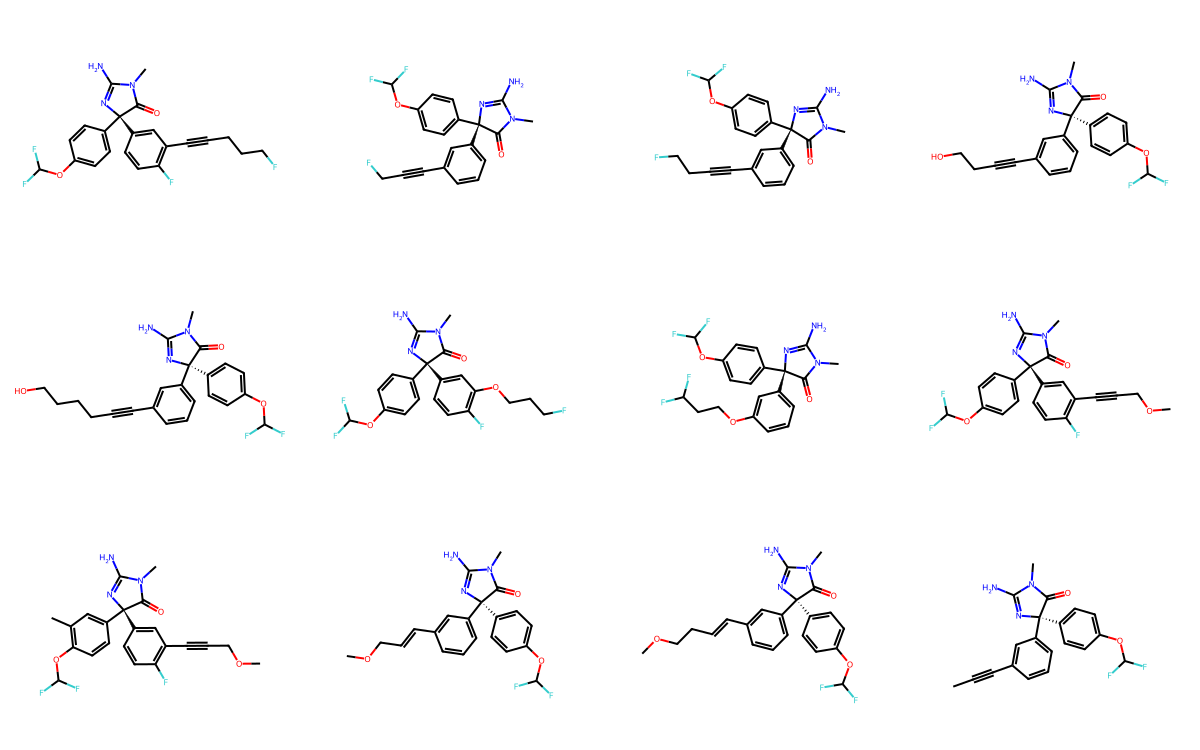

In [33]:
# ============================================================
# VISUALIZE MOLECULES FROM THE DATASET
# We need to reload with ECFP featurizer to access SMILES strings,
# because the GraphConv featurizer stores graph objects, not SMILES.
# ============================================================

# Load the same BACE dataset but with ECFP featurizer
# ECFP (Extended Connectivity Fingerprint) stores molecular IDs as SMILES strings
# which we need for visualization — the GraphConv featurizer doesn't preserve them
try:
    # Reload dataset with ECFP featurizer to access SMILES identifiers
    tasks2, datasets2, _ = dc.molnet.load_bace_classification(
        featurizer='ECFP', splitter='scaffold')  # Same scaffold split for consistency
    
    # Extract the first 12 SMILES strings from the training set
    # dataset.ids contains the molecule identifiers (SMILES strings)
    smiles_list = datasets2[0].ids[:12]
    
    # Convert SMILES strings to RDKit Mol objects for rendering
    # Chem.MolFromSmiles() parses SMILES; returns None if parsing fails
    # We filter out None values to handle any invalid SMILES gracefully
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if Chem.MolFromSmiles(s) is not None]
    
    # Render molecules in a grid layout: 4 molecules per row, each 300x250 pixels
    # MolsToGridImage creates a PIL image with 2D structure diagrams
    img = Draw.MolsToGridImage(mols[:12], molsPerRow=4, subImgSize=(300, 250))
    
    # Display the grid image in the Jupyter notebook
    display(img)
    
except Exception as e:
    # Gracefully handle errors (e.g., display not available in non-notebook environments)
    print(f'Visualization skipped: {e}')


## 3. Train a Graph Convolutional Network (GCN)

DeepChem's `GraphConvModel` implements a Graph Convolutional Network based on the architecture by Kipf & Welling (2017). Here's what happens under the hood:

### Architecture
1. **Input Layer**: Takes the molecular graph (atom features + adjacency matrix)
2. **Graph Convolution Layers**: Apply message passing — each atom aggregates information from its bonded neighbors using learned weight matrices. Mathematically: H^(l+1) = σ(D^(-1/2) A D^(-1/2) H^(l) W^(l)), where A is the adjacency matrix, D is the degree matrix, H is the node feature matrix, W is the learnable weight matrix, and σ is an activation function (ReLU)
3. **Graph Pooling (Readout)**: Aggregates all atom representations into a single molecular vector (using sum or mean pooling)
4. **Dense Layers**: Standard fully-connected layers that take the molecular vector and output a prediction

### Training Concepts
- **Epoch**: One complete pass through the entire training dataset. We train for 50 epochs, meaning the model sees every training molecule 50 times.
- **Loss Function**: Cross-entropy loss for binary classification — measures how far the model's predicted probabilities are from the true labels (0 or 1). Lower loss = better predictions.
- **Optimizer**: Adam optimizer (Adaptive Moment Estimation) — an advanced variant of stochastic gradient descent that adapts the learning rate for each parameter. It combines momentum (remembering past gradients) with RMSprop (scaling by running average of gradient magnitudes).
- **Learning Rate (0.001)**: Controls the step size during optimization. Too high → training is unstable and overshoots. Too low → training is slow and may get stuck. 0.001 is a common default.
- **Dropout (0.2)**: Randomly sets 20% of neuron outputs to zero during training. This is a regularization technique that prevents overfitting by forcing the network to learn redundant representations.
- **Batch Size (64)**: Number of molecules processed together before updating weights. Larger batches give more stable gradient estimates but use more memory.

**Reference:** Kipf, T.N. & Welling, M. (2017). Semi-Supervised Classification with Graph Convolutional Networks. ICLR


In [6]:
# ============================================================
# BUILD AND TRAIN THE GRAPH CONVOLUTIONAL NETWORK (GCN)
# This cell is written to fail gracefully on environments where
# DeepChem graph backends are unavailable.
# ============================================================

losses = []
model_gcn = None
model_training_status = 'not_started'
model_training_message = ''

try:
    if hasattr(dc.models, 'GraphConvModel'):
        model_gcn = dc.models.GraphConvModel(
            n_tasks=1,
            mode='classification',
            dropout=0.2,
            batch_size=64,
            learning_rate=0.001
        )
        model_name = 'GraphConvModel'
    elif hasattr(dc.models, 'GCNModel'):
        import dgl  # noqa: F401
        model_gcn = dc.models.GCNModel(
            n_tasks=1,
            mode='classification',
            dropout=0.2,
            batch_size=64,
            learning_rate=0.001
        )
        model_name = 'GCNModel'
    else:
        raise RuntimeError('No compatible graph model is available in this DeepChem installation.')

    print(f'Training {model_name}...')

    for epoch in range(50):
        loss = model_gcn.fit(train_dataset, nb_epoch=1)
        losses.append(float(loss))

        if (epoch + 1) % 10 == 0:
            train_score = model_gcn.evaluate(
                train_dataset,
                [dc.metrics.Metric(dc.metrics.roc_auc_score)]
            )
            valid_score = model_gcn.evaluate(
                valid_dataset,
                [dc.metrics.Metric(dc.metrics.roc_auc_score)]
            )
            print(
                f'Epoch {epoch+1}: '
                f'Train AUC={list(train_score.values())[0]:.3f}, '
                f'Valid AUC={list(valid_score.values())[0]:.3f}'
            )

    model_training_status = 'trained'
    model_training_message = 'Training complete.'
    print(model_training_message)

except Exception as e:
    model_gcn = None
    model_training_status = 'skipped'
    model_training_message = f'Graph model training skipped due to environment/backend issue: {e}'
    print(model_training_message)
    print('The Random Forest baseline below will still run normally.')

Training GCNModel...


C:\Users\serbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\deepchem\models\torch_models\torch_model.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  avg_loss = float(avg_loss) / averaged_batches


Epoch 10: Train AUC=0.888, Valid AUC=0.649
Epoch 20: Train AUC=0.910, Valid AUC=0.674
Epoch 30: Train AUC=0.918, Valid AUC=0.689
Epoch 40: Train AUC=0.930, Valid AUC=0.700
Epoch 50: Train AUC=0.928, Valid AUC=0.702
Training complete.


In [7]:
# ============================================================
# EVALUATE GCN ON THE HELD-OUT TEST SET
# This gives us the final, unbiased performance estimate.
# The model has NEVER seen these molecules during training.
# ============================================================

if model_gcn is None:
    test_score_gcn = {'roc_auc_score': np.nan}
    print('GCN evaluation skipped because graph model training did not complete in this environment.')
else:
    test_score_gcn = model_gcn.evaluate(
        test_dataset,
        [dc.metrics.Metric(dc.metrics.roc_auc_score)]
    )
    print(f'GCN Test AUC-ROC: {list(test_score_gcn.values())[0]:.3f}')

GCN Test AUC-ROC: 0.840


## 4. Train a Random Forest Baseline

For a fair comparison, we train a **Random Forest** classifier using **Morgan fingerprints** (ECFP4). This is the classical ML approach from Day 2 (Evaluation).

### Why Compare?
- GNNs are not always better! On small datasets (<5,000 molecules), classical methods like Random Forests with fingerprints often perform comparably or even better.
- Random Forests are faster to train, easier to interpret, and require less hyperparameter tuning.
- GNNs tend to shine on **larger datasets** (>10,000 molecules) where they can learn complex structure-activity relationships that fingerprints miss.

### Morgan Fingerprints vs. Learned GNN Features
- **Morgan/ECFP4**: Fixed-length binary vectors (2048 bits). Each bit indicates the presence/absence of a particular circular substructure (radius=2). Hand-designed and universal — the same fingerprint for all tasks.
- **GNN Features**: Learned real-valued vectors. The GNN learns which structural features matter *for this specific task*. Task-specific and adaptive, but requires more data to learn effectively.


In [10]:
# ============================================================
# TRAIN A RANDOM FOREST BASELINE WITH MORGAN FINGERPRINTS
# This provides a classical ML comparison for the GCN.
# ============================================================

# Reload the BACE dataset with ECFP (Extended Connectivity Fingerprint) featurizer
# ECFP converts each molecule into a fixed-length binary vector (2048 bits by default)
# Each bit represents the presence/absence of a circular substructure at radius 2
# splitter='scaffold' ensures the SAME scaffold-based split as the GCN for fair comparison
tasks_ecfp, datasets_ecfp, transformers_ecfp = dc.molnet.load_bace_classification(
    featurizer='ECFP',       # Morgan/ECFP4 fingerprints as feature vectors
    splitter='scaffold'      # Same scaffold split as GCN for fair comparison
)

# Unpack the three splits (train, validation, test)
train_ecfp, valid_ecfp, test_ecfp = datasets_ecfp

# Initialize a Random Forest classifier with 500 decision trees
# n_estimators=500: number of trees in the forest (more trees = more stable predictions)
# random_state=42: fixed seed for reproducibility (same results every run)
# n_jobs=-1: use all available CPU cores for parallel training (speeds up significantly)
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

# Train the Random Forest on fingerprint features (X) and binary labels (y)
# train_ecfp.X: 2D array of shape (n_molecules, 2048) — the fingerprint matrix
# train_ecfp.y.ravel(): 1D array of binary labels (0=inactive, 1=active)
# .ravel() flattens the array from shape (n,1) to (n,) as sklearn expects
rf.fit(train_ecfp.X, train_ecfp.y.ravel())

# Generate predicted probabilities for the positive class (active=1) on the test set
# predict_proba returns a 2D array: columns = [P(inactive), P(active)]
# We take [:, 1] to get the probability of being active (needed for AUC-ROC)
y_pred_rf = rf.predict_proba(test_ecfp.X)[:, 1]

# Compute AUC-ROC for the Random Forest predictions
# This measures how well the model ranks active molecules above inactive ones
auc_rf = roc_auc_score(test_ecfp.y.ravel(), y_pred_rf)

# Print the test AUC-ROC for comparison with the GCN
print(f'Random Forest Test AUC-ROC: {auc_rf:.3f}')


Random Forest Test AUC-ROC: 0.857


## 5. Compare Models

Now we compare the GCN and Random Forest side by side. Key considerations:

### When GNNs Outperform Random Forests
- **Large datasets** (>10,000 molecules): More data lets GNNs learn better representations
- **Complex SAR**: When structure-activity relationships are non-linear and depend on global molecular topology
- **Novel scaffolds**: GNNs may generalize better to entirely new chemical series
- **Multi-task learning**: GNNs can share learned representations across multiple related prediction tasks

### When Random Forests May Win
- **Small datasets** (<5,000 molecules): Not enough data for GNNs to learn meaningful representations
- **Well-characterized targets**: When hand-crafted features (e.g., specific pharmacophore patterns) capture the key SAR
- **Interpretability needed**: Random Forests allow feature importance analysis (which fingerprint bits matter)
- **Speed**: RF trains in seconds; GNNs may take minutes to hours on larger datasets

### Practical Advice
Always try both! In real drug discovery projects, ensemble methods that combine GNN and RF predictions often outperform either alone.


In [11]:
# ============================================================
# COMPARE GCN vs RANDOM FOREST PERFORMANCE
# Side-by-side comparison of the two approaches.
# ============================================================

gcn_auc = list(test_score_gcn.values())[0]

results = pd.DataFrame({
    'Model': ['Random Forest (ECFP4)', 'Graph Conv Network'],
    'Test AUC-ROC': [auc_rf, gcn_auc]
})

print(results.to_string(index=False))
print()

if np.isnan(gcn_auc):
    print('GCN result unavailable in this runtime (graph backend issue).')
    print('Use the RF score above, or run this notebook in a clean environment with working DGL/Torch.')
elif gcn_auc > auc_rf:
    print('GCN outperforms RF on this dataset!')
else:
    print('RF is competitive with (or better than) GCN on this dataset.')
    print('This is common for smaller datasets like BACE (~1500 molecules).')

                Model  Test AUC-ROC
Random Forest (ECFP4)      0.857156
   Graph Conv Network      0.840217

RF is competitive with (or better than) GCN on this dataset.
This is common for smaller datasets like BACE (~1500 molecules).


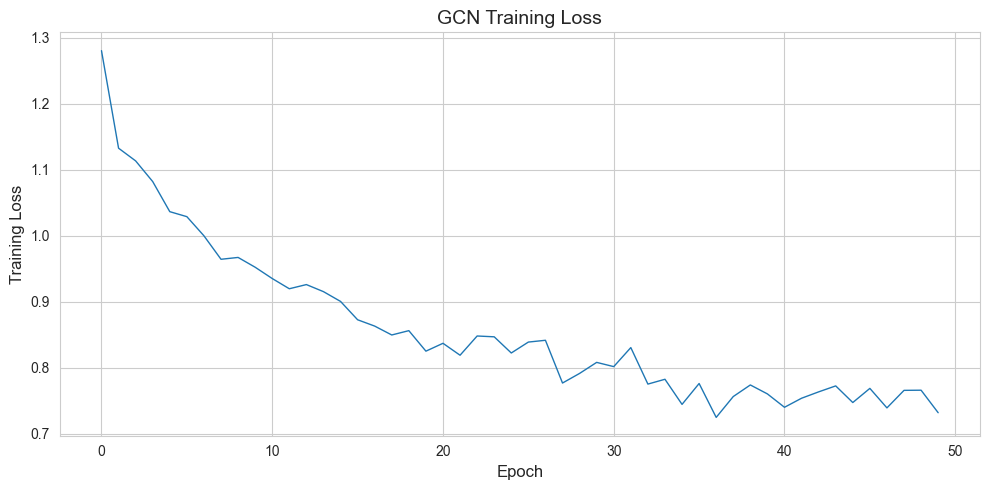

In [8]:
# ============================================================
# PLOT THE GCN TRAINING LOSS CURVE
# If graph training was skipped, show an explicit message instead
# of an empty plot.
# ============================================================

plt.figure(figsize=(10, 5))

if losses:
    plt.plot(losses, color='#1f77b4', linewidth=1)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Training Loss', fontsize=12)
    plt.title('GCN Training Loss', fontsize=14)
else:
    plt.text(
        0.5,
        0.5,
        'No GCN loss curve available.\nGraph training was skipped in this environment.',
        ha='center',
        va='center',
        fontsize=12
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks([])
    plt.yticks([])
    plt.title('GCN Training Loss Unavailable', fontsize=14)

plt.tight_layout()
plt.show()

if not losses:
    print(model_training_message)

## 6. (Bonus) Try the HIV Dataset

The **HIV dataset** has ~41,000 molecules — significantly larger than BACE. This is where GNNs should have a **bigger advantage** over fingerprint-based methods, because:
- More training data allows the GNN to learn richer, more nuanced molecular representations
- The chemical diversity is greater, so learned features can capture more complex SAR patterns
- Morgan fingerprints have a fixed vocabulary of substructures, while GNNs can adapt their feature extraction to the specific task

**Note:** Training on the HIV dataset takes significantly longer (5-15 minutes depending on your hardware). Uncomment the code below to try it.


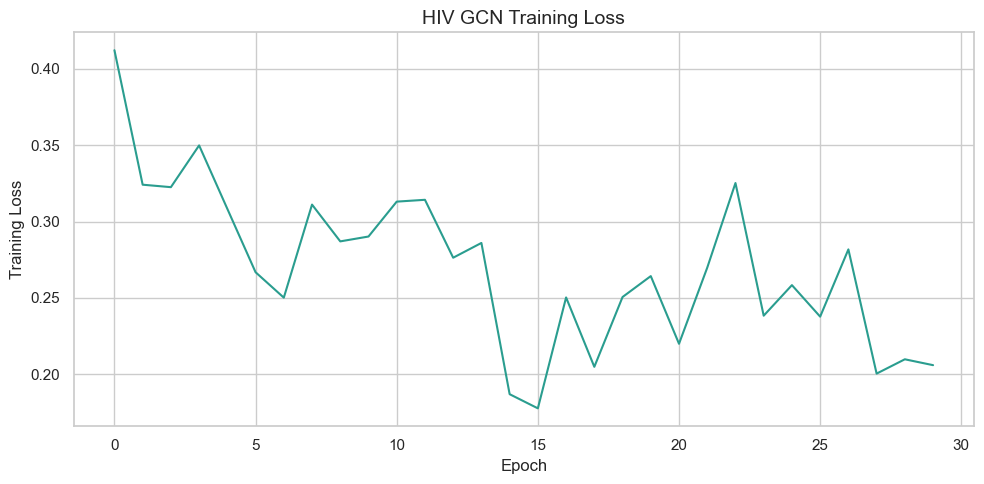

In [ ]:
# # ============================================================
# # (BONUS) HIV DATASET — LARGER DATASET WHERE GNNs SHINE
# # The HIV CSV contains a few invalid SMILES entries. DeepChem skips them,
# # but the per-datapoint RDKit messages are noisy, so we silence stderr during
# # featurization and then continue with the valid molecules.
# # ============================================================

# import contextlib
# import os

# with open(os.devnull, 'w') as devnull, contextlib.redirect_stderr(devnull):
#     tasks_hiv, datasets_hiv, _ = dc.molnet.load_hiv(
#         featurizer=dc.feat.MolGraphConvFeaturizer(),
#         splitter='scaffold'
#     )

# train_hiv, valid_hiv, test_hiv = datasets_hiv

# print(f'HIV dataset: {len(train_hiv)} train, {len(valid_hiv)} valid, {len(test_hiv)} test')

# if hasattr(dc.models, 'GCNModel'):
#     model_hiv = dc.models.GCNModel(
#         n_tasks=1,
#         mode='classification',
#         dropout=0.2,
#         batch_size=64,
#         learning_rate=0.001
#     )
#     model_hiv_name = 'GCNModel'
# else:
#     raise RuntimeError('HIV bonus section requires DeepChem GCNModel in this environment.')

# print(f'Training {model_hiv_name} on HIV...')

# hiv_losses = []
# for epoch in range(30):
#     loss = model_hiv.fit(train_hiv, nb_epoch=1)
#     hiv_losses.append(float(loss))

#     if (epoch + 1) % 5 == 0:
#         valid_score_hiv = model_hiv.evaluate(
#             valid_hiv,
#             [dc.metrics.Metric(dc.metrics.roc_auc_score)]
#         )
#         print(f'Epoch {epoch+1}: Valid AUC={list(valid_score_hiv.values())[0]:.3f}')

# score_hiv = model_hiv.evaluate(test_hiv, [dc.metrics.Metric(dc.metrics.roc_auc_score)])
# print(f'HIV GCN Test AUC: {list(score_hiv.values())[0]:.3f}')

# # Plot HIV training loss curve
# plt.figure(figsize=(10, 5))
# plt.plot(hiv_losses, color='#2a9d8f', linewidth=1.5)
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title('HIV GCN Training Loss', fontsize=14)
# plt.tight_layout()
# plt.show()

<!-- ## SpikerBot Neural Motifs: Physiology as Graphs

### Cross-Domain Insight: From Molecular Graphs to Brain Graphs

Everything you've learned about Graph Neural Networks for molecules applies **directly** to neuroscience data! The mathematical framework is identical — only the domain interpretation changes:

| Molecular Graphs | Neural Graphs |
|---|---|
| **Nodes** = atoms (C, N, O, ...) | **Nodes** = recording channels/electrodes |
| **Node features** = atomic number, charge, hybridization | **Node features** = firing rate, CV of ISI, mean amplitude |
| **Edges** = chemical bonds | **Edges** = correlations between electrode pairs |
| **Edge features** = bond type, conjugation | **Edge features** = correlation strength, time lag |
| **Graph-level task** = predict molecular property | **Graph-level task** = classify brain state or predict drug effect |

### How Neural Recording Data Becomes a Graph

When you record from the brain (or from a programmable **SpikerBot** neural stimulator), you typically have multiple recording channels. Each channel records voltage over time, producing **spike trains** — sequences of action potentials. To build a graph:

1. **Nodes**: Each recording electrode/channel becomes a node
2. **Node features**: Compute spike train statistics for each channel — firing rate, coefficient of variation of inter-spike intervals (CV-ISI), burst index, mean amplitude, etc.
3. **Edges**: Compute pairwise correlations between channels (cross-correlation, coherence, Granger causality). If the correlation exceeds a threshold, draw an edge between those two nodes.
4. **Edge features**: The strength and timing of correlations (e.g., correlation coefficient, phase lag)
5. **Feed the graph to a GNN**: The SAME message passing framework you used for molecules now classifies brain states, predicts drug effects, or detects pathological activity

### Programmable SpikerBot Neural Motifs

The **SpikerBot** is a programmable neural stimulator (Marzullo & Gage, 2012) that can generate three fundamental firing patterns (motifs):

1. **Tonic Firing** (regular, evenly-spaced spikes)
   - Found in: motor neurons during sustained contraction, cerebellar Purkinje cells at rest
   - Characterized by: very low CV-ISI (~0), constant firing rate
   - On SpikerBot: constant-frequency stimulation (e.g., every 50 ms = 20 Hz)
   - Drug relevance: Na+ channel blockers (lidocaine) decrease tonic firing rate

2. **Burst Firing** (clusters of rapid spikes separated by pauses)
   - Found in: thalamocortical neurons during sleep spindles, dopamine neurons during reward, hippocampal place cells
   - Characterized by: high CV-ISI (>1), bimodal ISI distribution (short intra-burst, long inter-burst)
   - On SpikerBot: 3-4 rapid pulses at 100 Hz, then 200-400 ms pause, repeat
   - Drug relevance: T-type Ca2+ channel blockers (ethosuximide) suppress burst firing in absence epilepsy

3. **Irregular/Poisson Firing** (random intervals)
   - Found in: cortical neurons during wakefulness, most brain areas under active conditions
   - Characterized by: CV-ISI ≈ 1 (hallmark of a Poisson process), exponentially distributed ISIs
   - On SpikerBot: randomized stimulation intervals drawn from an exponential distribution
   - Drug relevance: GABA-A agonists (benzodiazepines) can reduce firing rate and alter regularity

### Spike Train Statistics as Node Features

Just as we compute molecular descriptors (MW, LogP, TPSA) to characterize molecules, we compute **spike train statistics** to characterize neural activity:

- **Firing Rate** (Hz): Total spikes / recording duration — analogous to molecular weight
- **CV of ISI** (Coefficient of Variation): std(ISI) / mean(ISI) — the key statistic that distinguishes firing patterns:
  - CV ≈ 0: perfectly regular (tonic)
  - CV ≈ 1: random (Poisson/irregular)
  - CV > 1: bursty (more variable than random)
- **Burst Index**: Fraction of spikes occurring in bursts — analogous to aromaticity index
- **Mean Amplitude**: Average spike height — reflects recording quality and cell type

### GNNs for Brain Connectivity Data

Recent work has applied GNNs to brain connectivity graphs with great success:
- **Bessadok, A., Mahjoub, M.A., & Rekik, I. (2022)**. Graph Neural Networks in Network Neuroscience. *Medical Image Analysis*, 79, 102418. — Comprehensive review of GNN applications in brain connectivity analysis, including disease classification, brain age prediction, and connectome analysis.

### The *Drosophila* Connectome: The Ultimate Neural Graph

The most spectacular example of a biological graph in neuroscience is the **complete adult *Drosophila* brain connectome**, reconstructed by the FlyWire consortium (Dorkenwald et al., 2024, *Nature* 634:124–138). Using serial-section electron microscopy and automated segmentation with human proofreading, the FlyWire team mapped:

- **~140,000 neurons** (nodes)
- **~50 million synaptic connections** (directed, weighted edges)
- Complete cell-type annotations for the entire brain (Schlegel et al., 2024, *Nature* 634:139–152)

This **IS** a graph — and it is the same mathematical object as the molecular graphs you trained GCNs on above. The adjacency matrix is ~140,000 × 140,000 (sparse), each neuron node has features (cell type, neurotransmitter, morphology), and each synaptic edge has features (synapse count, pre/post compartment). Message passing on this graph lets a GNN:

- **Predict neuron types** from connectivity patterns alone
- **Classify circuit motifs** (e.g., feedforward vs. recurrent)
- **Identify potential drug targets** by finding hub neurons or critical circuit bottlenecks

### GluClα Channels: Where Neural Circuits Meet Drug Targets

Dr. Serbe-Kamp's research on *Drosophila* motion detection also revealed the role of **GluClα** (glutamate-gated chloride channel alpha) in **motion opponency** — the process by which neurons that detect opposite directions of motion inhibit each other. GluClα channels are members of the **Cys-loop ligand-gated ion channel superfamily**, which also includes:

- **GABA-A receptors** — targets of benzodiazepines, barbiturates, and general anaesthetics
- **Nicotinic acetylcholine receptors (nAChRs)** — targets of nicotine and smoking cessation drugs
- **Glycine receptors** — targets of strychnine

Crucially, **GluCl channels are the target of ivermectin**, the antiparasitic drug whose discovery earned the **2015 Nobel Prize in Physiology or Medicine** (William C. Campbell and Satoshi Ōmura). Ivermectin activates GluCl channels in parasitic nematodes and arthropods, causing paralysis. Understanding which neural circuits depend on GluClα — as Dr. Serbe-Kamp's work reveals — helps identify:

1. **Which channel subtypes** are essential for specific circuit functions (and thus are viable drug targets)
2. **Species-specific differences** in GluCl expression that explain why ivermectin kills parasites but is safe in mammals
3. **New therapeutic opportunities** — if a circuit motif depends on a specific receptor, that receptor becomes a candidate target for circuit-level drug design

This exemplifies how **connectomics + molecular pharmacology** converges: GNN analysis of the connectome graph identifies critical circuit nodes, and molecular GNNs (like the ones you trained above) can then screen for drugs that modulate the receptors at those nodes.

### The Key Takeaway

**Students who learn molecular GNNs can immediately work in computational neuroscience** — and vice versa! The mathematical framework (message passing on graphs) is domain-agnostic. The only difference is what the nodes, edges, and features represent. This is the power of graph-based thinking: it provides a unified computational framework across biology.

**Reference:** Marzullo, T.C. & Gage, G.J. (2012). The SpikerBox: A Low Cost, Open-Source BioAmplifier for Increasing Public Participation in Neuroscience Inquiry. *Advances in Physiology Education*, 36(2), 2-14. -->


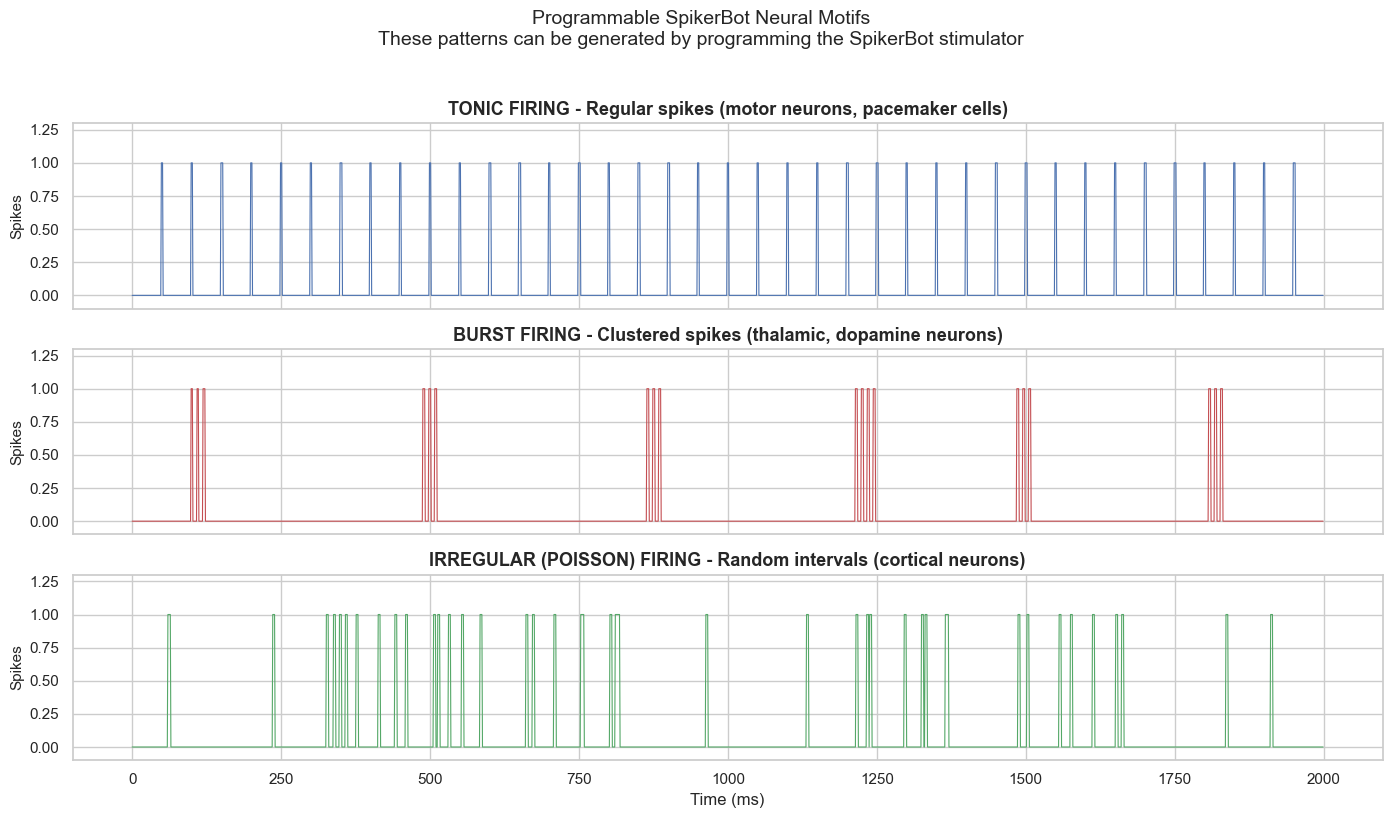


=== SPIKE TRAIN STATISTICS (analogous to molecular descriptors) ===
  Tonic:
    Spike count: 39
    Firing rate: 19.5 Hz
    Mean ISI: 50.0 ms
    CV(ISI): 0.000  (regular)
  Burst:
    Spike count: 19
    Firing rate: 9.5 Hz
    Mean ISI: 96.0 ms
    CV(ISI): 1.466  (bursty/very irregular)
  Irregular/Poisson:
    Spike count: 43
    Firing rate: 21.5 Hz
    Mean ISI: 44.1 ms
    CV(ISI): 1.085  (bursty/very irregular)

=== CONNECTION TO GNNs ===
In a multi-electrode recording (e.g., SpikerBot with multiple channels):
  Nodes = electrodes/channels
  Node features = [firing_rate, CV_ISI, mean_amplitude, ...]
  Edges = correlations between channels
  -> Feed to GNN -> Classify brain state or predict drug effect

This is EXACTLY the same framework as molecular GNNs!
  Molecular: Nodes=atoms, Edges=bonds, Task=predict toxicity
  Neural: Nodes=electrodes, Edges=correlations, Task=classify brain state
NEURAL CIRCUIT GRAPH (simplified Drosophila motion circuit)

Adjacency matrix (synapse c

In [43]:
# ============================================================
# PROGRAMMABLE SPIKERBOT NEURAL MOTIFS
# This demonstrates how neural firing patterns can be represented
# and analyzed with the same computational tools as molecular data.
# The SpikerBot can be programmed to generate these motifs.
# Reference: Marzullo & Gage (2012), Adv. Physiol. Educ. 36:2-14
# ============================================================

# numpy: numerical computing library for array operations and random number generation
import numpy as np

# matplotlib.pyplot: plotting library for creating spike raster visualizations
import matplotlib.pyplot as plt

# Set random seed for reproducibility
# This ensures the same random spike trains are generated every time
np.random.seed(42)

# --- Simulate three neural firing motifs ---
# These are the patterns you can program the SpikerBot to generate
# and observe the muscle/neural response

# Total simulation time in seconds
T = 2.0  # 2 seconds of recording

# Time resolution: 1 ms (0.001 s), which is 1000 Hz sampling rate
# This is typical for neural data acquisition systems
dt = 0.001  # 1 ms time resolution (1000 Hz sampling, typical for neural data)

# Create the time array from 0 to T in steps of dt
# This gives us 2000 time points for our 2-second simulation
t = np.arange(0, T, dt)  # Time array

# MOTIF 1: TONIC FIRING (regular, evenly-spaced spikes)
# Found in: motor neurons during sustained contraction, cerebellar Purkinje cells
# On SpikerBot: constant-frequency stimulation (e.g., every 50 ms = 20 Hz)
# Drug effect: reducing Na+ conductance (lidocaine) decreases firing rate

# Set the firing rate to 20 Hz (20 spikes per second)
tonic_rate = 20  # Hz (spikes per second)

# Calculate the Inter-Spike Interval (time between consecutive spikes)
# ISI = 1/rate = 1/20 = 0.05 seconds = 50 ms
tonic_isi = 1.0 / tonic_rate  # Inter-Spike Interval in seconds (50 ms)

# Generate perfectly regular spike times using np.arange
# Spikes occur at 50ms, 100ms, 150ms, ..., up to 2000ms
tonic_spike_times = np.arange(tonic_isi, T, tonic_isi)  # Regular spike times

# MOTIF 2: BURST FIRING (clusters of rapid spikes with pauses)
# Found in: thalamocortical neurons (sleep spindles), dopamine neurons (reward), hippocampus
# On SpikerBot: 3-4 rapid pulses at 100 Hz, then 300 ms pause, repeat
# Drug effect: T-type Ca2+ channel blockers (ethosuximide) suppress burst firing

# Initialize empty list to collect burst spike times
burst_spike_times = []

# Start the first burst at 100 ms into the recording
burst_time = 0.1  # Start time

# Generate bursts until we exceed the simulation duration
while burst_time < T:
    # Generate a burst: 3-4 spikes at 100 Hz (10 ms apart)
    # np.random.randint(3, 5) gives either 3 or 4 spikes per burst
    n_spikes_in_burst = np.random.randint(3, 5)  # 3-4 spikes per burst
    
    # Add each spike in the burst, separated by 10 ms (100 Hz intra-burst frequency)
    for j in range(n_spikes_in_burst):
        burst_spike_times.append(burst_time + j * 0.01)  # 10 ms ISI within burst
    
    # Add inter-burst interval: 200-400 ms pause between bursts
    # This creates the characteristic burst-pause-burst-pause pattern
    burst_time += n_spikes_in_burst * 0.01 + np.random.uniform(0.2, 0.4)

# Convert to numpy array and clip to simulation duration
# Remove any spikes that fall after our 2-second window
burst_spike_times = np.array([s for s in burst_spike_times if s < T])

# MOTIF 3: IRREGULAR / POISSON FIRING (random intervals)
# Found in: cortical neurons during wakefulness, most brain areas
# On SpikerBot: randomized stimulation intervals from exponential distribution
# The Poisson process is the simplest model of "random" neural firing
# Drug effect: GABA-A agonists (benzodiazepines) can make firing more irregular/slower

# Average rate of 20 Hz (same as tonic, for fair comparison of statistics)
irregular_rate = 20  # Average rate (Hz) - same as tonic for fair comparison

# Generate inter-spike intervals from an exponential distribution
# For a Poisson process, ISIs are exponentially distributed with mean = 1/rate
# Generate 100 ISIs (more than enough for 2 seconds at 20 Hz)
irregular_isis = np.random.exponential(1.0 / irregular_rate, size=100)  # Exponential ISIs

# Convert ISIs to spike times using cumulative sum
# If ISIs are [0.03, 0.07, 0.02, ...], spike times are [0.03, 0.10, 0.12, ...]
irregular_spike_times = np.cumsum(irregular_isis)  # Cumulative sum gives spike times

# Clip spike times to our simulation window [0, T)
irregular_spike_times = irregular_spike_times[irregular_spike_times < T]  # Clip to T

# --- Create spike raster plots ---
# Create a figure with 3 vertically-stacked subplots sharing the x-axis
# figsize=(14, 8): wide enough to see individual spikes, tall enough for 3 panels
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Helper function to create a spike train voltage trace from spike times
# This converts a list of spike times into a binary time series for plotting
def spikes_to_trace(spike_times, t, spike_height=1.0, spike_width=0.002):
    # Initialize an array of zeros (no spikes) with the same length as the time array
    trace = np.zeros_like(t)
    # For each spike time, set the trace to spike_height in a small window around it
    for st in spike_times:
        # Create a boolean mask: True for time points within spike_width of the spike time
        mask = np.abs(t - st) < spike_width
        # Set those time points to the spike height (creates a narrow rectangular pulse)
        trace[mask] = spike_height
    # Return the complete trace array
    return trace

# Plot tonic firing pattern (blue, top panel)
# Convert spike times to a plottable voltage trace
trace_tonic = spikes_to_trace(tonic_spike_times, t)
# Plot the trace: time in milliseconds on x-axis, spikes on y-axis
axes[0].plot(t * 1000, trace_tonic, 'b-', linewidth=0.8)
# Label the y-axis
axes[0].set_ylabel('Spikes', fontsize=11)
# Add a descriptive title explaining where this pattern is found
axes[0].set_title('TONIC FIRING - Regular spikes (motor neurons, pacemaker cells)', fontsize=13, fontweight='bold')
# Set y-axis limits to give some padding above and below the spikes
axes[0].set_ylim(-0.1, 1.3)

# Plot burst firing pattern (red, middle panel)
# Convert burst spike times to a plottable voltage trace
trace_burst = spikes_to_trace(burst_spike_times, t)
# Plot in red to visually distinguish from tonic pattern
axes[1].plot(t * 1000, trace_burst, 'r-', linewidth=0.8)
# Label the y-axis
axes[1].set_ylabel('Spikes', fontsize=11)
# Add a descriptive title explaining where this pattern is found
axes[1].set_title('BURST FIRING - Clustered spikes (thalamic, dopamine neurons)', fontsize=13, fontweight='bold')
# Set y-axis limits for consistent scaling across panels
axes[1].set_ylim(-0.1, 1.3)

# Plot irregular firing pattern (green, bottom panel)
# Convert irregular spike times to a plottable voltage trace
trace_irreg = spikes_to_trace(irregular_spike_times, t)
# Plot in green to visually distinguish from other patterns
axes[2].plot(t * 1000, trace_irreg, 'g-', linewidth=0.8)
# Label the y-axis
axes[2].set_ylabel('Spikes', fontsize=11)
# Label the x-axis (only on bottom panel since they share x-axis)
axes[2].set_xlabel('Time (ms)', fontsize=12)
# Add a descriptive title explaining where this pattern is found
axes[2].set_title('IRREGULAR (POISSON) FIRING - Random intervals (cortical neurons)', fontsize=13, fontweight='bold')
# Set y-axis limits for consistent scaling across panels
axes[2].set_ylim(-0.1, 1.3)

# Add a super-title above all three panels explaining the overall figure
plt.suptitle('Programmable SpikerBot Neural Motifs\nThese patterns can be generated by programming the SpikerBot stimulator', fontsize=14, y=1.02)

# Adjust subplot spacing to prevent overlapping labels
plt.tight_layout()

# Render and display the figure in the notebook
plt.show()

# --- Compute spike train statistics ---
# These features are analogous to molecular descriptors!
# Just as we compute MW, LogP, TPSA for molecules,
# we compute firing rate, CV(ISI), burst index for spike trains.

# Define a function to compute and display spike train statistics
# This function takes spike times and a descriptive name as input
def compute_spike_stats(spike_times, name):
    # Inter-Spike Intervals: time between consecutive spikes
    # Need at least 2 spikes to compute intervals
    if len(spike_times) < 2:
        print(f"{name}: Too few spikes for statistics")
        return
    
    # Compute ISIs using np.diff (differences between consecutive elements)
    # If spike times are [0.05, 0.10, 0.15], ISIs are [0.05, 0.05]
    isis = np.diff(spike_times)  # Differences between consecutive spike times
    
    # Mean firing rate: total number of spikes divided by recording duration
    # Units: Hz (spikes per second)
    firing_rate = len(spike_times) / T
    
    # Mean ISI: average time between consecutive spikes
    # Convert from seconds to milliseconds (* 1000) for more intuitive display
    mean_isi = np.mean(isis) * 1000  # Convert to ms
    
    # CV of ISI (Coefficient of Variation): std(ISI) / mean(ISI)
    # This is the KEY statistic that distinguishes firing patterns:
    # CV = 0: perfectly regular (tonic) — all intervals are identical
    # CV = 1: Poisson (random) — intervals follow exponential distribution
    # CV > 1: bursty (more variable than random) — mix of short and long intervals
    cv_isi = np.std(isis) / np.mean(isis)
    
    # Print all computed statistics in a formatted display
    print(f"  {name}:")
    print(f"    Spike count: {len(spike_times)}")
    print(f"    Firing rate: {firing_rate:.1f} Hz")
    print(f"    Mean ISI: {mean_isi:.1f} ms")
    # Print CV-ISI with an interpretation label
    print(f"    CV(ISI): {cv_isi:.3f}  {'(regular)' if cv_isi < 0.3 else '(irregular)' if cv_isi < 0.8 else '(bursty/very irregular)'}")

# Print header for the statistics section
print("\n=== SPIKE TRAIN STATISTICS (analogous to molecular descriptors) ===")

# Compute and display statistics for each of the three motifs
# Compare the CV-ISI values across motifs — this is the key distinguishing feature
compute_spike_stats(tonic_spike_times, "Tonic")
compute_spike_stats(burst_spike_times, "Burst")
compute_spike_stats(irregular_spike_times, "Irregular/Poisson")

# Print the connection between neural graphs and molecular graphs
# This reinforces the cross-domain insight that is the key takeaway
print("\n=== CONNECTION TO GNNs ===")
print("In a multi-electrode recording (e.g., SpikerBot with multiple channels):")
print("  Nodes = electrodes/channels")
print("  Node features = [firing_rate, CV_ISI, mean_amplitude, ...]")
print("  Edges = correlations between channels")
print("  -> Feed to GNN -> Classify brain state or predict drug effect")
print("\nThis is EXACTLY the same framework as molecular GNNs!")
print("  Molecular: Nodes=atoms, Edges=bonds, Task=predict toxicity")
print("  Neural: Nodes=electrodes, Edges=correlations, Task=classify brain state")

# ============================================================
# SIMPLE NEURAL CIRCUIT GRAPH
# This demonstrates a 5-neuron circuit represented as a graph,
# mirroring how the Drosophila connectome is structured.
# In the real connectome (Dorkenwald et al., 2024), there are
# ~140,000 neurons and ~50 million synapses. Here we show the
# same concept with 5 neurons and directed synaptic connections.
# ============================================================

# --- Define a simple 5-neuron circuit ---
# Inspired by the T4/T5 motion detection circuit in Drosophila
# (Serbe et al., 2016, Neuron 92:227-239)
#
# Neuron 0: Photoreceptor (input)
# Neuron 1: Lamina interneuron L1 (excitatory relay)
# Neuron 2: Lamina interneuron L2 (excitatory relay)
# Neuron 3: Medulla interneuron Mi1 (excitatory, feeds T5)
# Neuron 4: T5 direction-selective neuron (output)

neuron_names = ["Photoreceptor", "L1", "L2", "Mi1", "T5 (output)"]
n_neurons = len(neuron_names)

# Adjacency matrix: A[i][j] = synapse count from neuron i -> neuron j
# This is a DIRECTED graph (synapses have a pre- and post-synaptic neuron)
# In the real connectome, edge weights are synapse counts (can be hundreds)
adjacency = np.array([
    # To:  Photo  L1    L2    Mi1   T5
    [0,    12,   8,    0,    0],   # Photoreceptor -> L1 (12 synapses), L2 (8)
    [0,    0,    0,    15,   0],   # L1 -> Mi1 (15 synapses)
    [0,    0,    0,    5,    10],  # L2 -> Mi1 (5), T5 (10)
    [0,    0,    0,    0,    20],  # Mi1 -> T5 (20 synapses)
    [0,    0,    0,    0,    0],   # T5 is output (no outgoing in this subgraph)
])

# Node features: [firing_rate (Hz), CV_ISI]
# These are the same spike train statistics computed above,
# now used as features for each neuron node in the graph
node_features = np.array([
    [30.0, 0.10],  # Photoreceptor: high rate, very regular (tonic)
    [25.0, 0.20],  # L1: moderate rate, fairly regular
    [22.0, 0.25],  # L2: moderate rate, fairly regular
    [18.0, 0.60],  # Mi1: lower rate, more variable
    [15.0, 1.20],  # T5: lowest rate, bursty (direction-selective responses)
])

# --- Display the neural circuit graph structure ---
print("=" * 65)
print("NEURAL CIRCUIT GRAPH (simplified Drosophila motion circuit)")
print("=" * 65)

print("\nAdjacency matrix (synapse counts, neuron i -> neuron j):")
header = "  ".join(f"{n[:5]:>5}" for n in neuron_names)
print(f"  {'':<16} {header}")
for i in range(n_neurons):
    row = "  ".join(f"{int(adjacency[i, j]):>5}" for j in range(n_neurons))
    print(f"  {neuron_names[i]:<16} {row}")

print(f"\nNode features (per neuron):")
print(f"  {'Neuron':<16} {'Firing Rate (Hz)':>17} {'CV_ISI':>8}")
for i in range(n_neurons):
    print(f"  {neuron_names[i]:<16} {node_features[i, 0]:>17.1f} {node_features[i, 1]:>8.2f}")

total_synapses = int(adjacency.sum())
print(f"\nGraph summary: {n_neurons} neurons, {total_synapses} total synapses")
print(f"Real Drosophila connectome: ~140,000 neurons, ~50,000,000 synapses")

# --- The key insight: same math, different biology ---
print("\n" + "=" * 65)
print("MOLECULAR GRAPH vs NEURAL GRAPH: SAME MATH!")
print("=" * 65)
print("  Molecular graph: nodes = atoms,   edges = bonds,    task = predict BACE activity")
print("  Neural graph:    nodes = neurons, edges = synapses, task = classify neuron type")
print("  Same message-passing framework. Same GNN architecture. Different biology!")
print("=" * 65)


## 7. Exercises

1. **Hyperparameter tuning**: Try different learning rates (0.0001, 0.001, 0.01), dropout rates (0.1, 0.2, 0.5), and number of epochs (20, 50, 100). Record the validation AUC for each configuration. Which combination works best?
2. **Deeper model**: Add more graph conv layers by exploring DeepChem's model options. Does a deeper model help? (Hint: very deep GNNs can suffer from "over-smoothing" where all node representations become similar)
3. **Different dataset**: Try the Tox21 dataset (`dc.molnet.load_tox21`) — this is a multi-task dataset with 12 toxicity endpoints. How does GCN performance vary across tasks?
4. **Chemprop**: Install and try Chemprop (`pip install chemprop`) — a message-passing neural network that is often state-of-the-art. How does it compare to DeepChem's GCN?


## References
- Wu, Z. et al. (2018). MoleculeNet: A Benchmark for Molecular Machine Learning. Chemical Science 9:513-530
- Kipf, T.N. & Welling, M. (2017). Semi-Supervised Classification with Graph Convolutional Networks. ICLR
- Yang, K. et al. (2019). Analyzing Learned Molecular Representations for Property Prediction. JCIM 59:3370-3388
- Stokes, J.M. et al. (2020). A Deep Learning Approach to Antibiotic Discovery. Cell 180:688-702
- Marzullo, T.C. & Gage, G.J. (2012). The SpikerBox: A Low Cost, Open-Source BioAmplifier for Increasing Public Participation in Neuroscience Inquiry. Advances in Physiology Education 36(2):2-14
- Bessadok, A., Mahjoub, M.A., & Rekik, I. (2022). Graph Neural Networks in Network Neuroscience. Medical Image Analysis 79:102418
- Dorkenwald, S. et al. (2024). Neuronal wiring diagram of an adult brain. Nature 634:124-138
- Schlegel, P. et al. (2024). Whole-brain annotation and multi-connectome cell typing of Drosophila. Nature 634:139-152
- Serbe, E., Meier, M., Leonhardt, A., & Borst, A. (2016). Comprehensive Characterization of the Major Presynaptic Elements to the Drosophila OFF Motion Detector. Neuron 92:227-239
